# 01 Python Data Processing and Analysis

This notebook loads, cleans, processes, merges, and analyses the NorthStar Urban Mobility and Logistics datasets using Python, Pandas, NumPy, and Matplotlib.

## 1. Setup and Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load NorthStar Dataset Files

In [3]:
data_path = "/content/drive/MyDrive/NorthStar_Assignment/data"

os.listdir(data_path)

['deliveries.csv',
 'customers.csv',
 'data_dictionary.csv',
 'hubs.csv',
 'incidents.csv',
 'app_events.csv',
 'vehicles.csv',
 'drivers.csv',
 'orders.csv',
 'complaints.csv',
 'README.txt',
 'clean_hubs.csv',
 'clean_vehicles.csv',
 'clean_drivers.csv',
 'clean_orders.csv',
 'clean_customers.csv',
 'clean_app_events.csv',
 'clean_deliveries.csv',
 'clean_complaints.csv',
 'clean_incidents.csv',
 'full_analysis.csv']

In [4]:
hubs = pd.read_csv(data_path + "/hubs.csv")
customers = pd.read_csv(data_path + "/customers.csv")
drivers = pd.read_csv(data_path + "/drivers.csv")
vehicles = pd.read_csv(data_path + "/vehicles.csv")
orders = pd.read_csv(data_path + "/orders.csv")
deliveries = pd.read_csv(data_path + "/deliveries.csv")
incidents = pd.read_csv(data_path + "/incidents.csv")
complaints = pd.read_csv(data_path + "/complaints.csv")
app_events = pd.read_csv(data_path + "/app_events.csv")
data_dictionary = pd.read_csv(data_path + "/data_dictionary.csv")

print("All files loaded successfully")

All files loaded successfully


## 3. Initial Data Inspection

In [5]:
orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [6]:
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [7]:
complaints.head()

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18


In [8]:
datasets = {
    "hubs": hubs,
    "customers": customers,
    "drivers": drivers,
    "vehicles": vehicles,
    "orders": orders,
    "deliveries": deliveries,
    "incidents": incidents,
    "complaints": complaints,
    "app_events": app_events
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Column names:", list(df.columns))


HUBS
Rows: 8
Columns: 5
Column names: ['hub_id', 'hub_name', 'zone', 'hub_type', 'capacity_score']

CUSTOMERS
Rows: 650
Columns: 9
Column names: ['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status']

DRIVERS
Rows: 170
Columns: 8
Column names: ['driver_id', 'base_zone', 'employment_type', 'years_experience', 'training_score', 'driver_rating', 'shift_preference', 'active_flag']

VEHICLES
Rows: 120
Columns: 8
Column names: ['vehicle_id', 'vehicle_type', 'assigned_zone', 'commission_date', 'battery_health_pct', 'odometer_km', 'maintenance_status', 'telematics_version']

ORDERS
Rows: 1250
Columns: 11
Column names: ['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag']

DELIVERIES
Rows: 950
Columns: 13
Column names: ['delivery_id', 'order_id', 'driver_id', 'v

## 4. Data Quality Checks

In [9]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.isnull().sum())


HUBS
hub_id            0
hub_name          0
zone              0
hub_type          0
capacity_score    0
dtype: int64

CUSTOMERS
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64

DRIVERS
driver_id           0
base_zone           0
employment_type     0
years_experience    0
training_score      7
driver_rating       0
shift_preference    0
active_flag         0
dtype: int64

VEHICLES
vehicle_id            0
vehicle_type          0
assigned_zone         0
commission_date       0
battery_health_pct    4
odometer_km           0
maintenance_status    0
telematics_version    0
dtype: int64

ORDERS
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone             

In [10]:
for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()
    print(f"{name}: {duplicate_count} duplicate rows")

hubs: 0 duplicate rows
customers: 0 duplicate rows
drivers: 0 duplicate rows
vehicles: 0 duplicate rows
orders: 0 duplicate rows
deliveries: 0 duplicate rows
incidents: 0 duplicate rows
complaints: 0 duplicate rows
app_events: 0 duplicate rows


## 5. Data Cleaning and Preparation

In [11]:
def clean_text_columns(df):
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()
    return df

for name, df in datasets.items():
    datasets[name] = clean_text_columns(df)

hubs = datasets["hubs"]
customers = datasets["customers"]
drivers = datasets["drivers"]
vehicles = datasets["vehicles"]
orders = datasets["orders"]
deliveries = datasets["deliveries"]
incidents = datasets["incidents"]
complaints = datasets["complaints"]
app_events = datasets["app_events"]

print("Text columns cleaned successfully")

Text columns cleaned successfully


In [12]:
zone_columns = {
    "customers": ["home_zone"],
    "drivers": ["base_zone"],
    "vehicles": ["assigned_zone"],
    "orders": ["pickup_zone", "dropoff_zone"],
    "hubs": ["zone"],
    "app_events": ["zone_context"]
}

for dataset_name, cols in zone_columns.items():
    df = datasets[dataset_name]
    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.title()

print("Zone names standardised successfully")

Zone names standardised successfully


In [13]:
date_columns = {
    "customers": ["signup_date"],
    "vehicles": ["commission_date"],
    "orders": ["order_created_at"],
    "deliveries": ["dispatch_time", "delivery_completed_at"],
    "incidents": ["reported_at"],
    "complaints": ["created_at"],
    "app_events": ["event_timestamp"]
}

for dataset_name, cols in date_columns.items():
    df = datasets[dataset_name]
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

print("Date columns converted successfully")

Date columns converted successfully


In [14]:
orders.dtypes

,0
order_id,object
customer_id,object
service_type,object
order_created_at,datetime64[ns]
promised_window_hours,int64
pickup_zone,object
dropoff_zone,object
priority_level,object
order_value,float64
booking_channel,object


In [15]:
deliveries.dtypes

,0
delivery_id,object
order_id,object
driver_id,object
vehicle_id,object
hub_id,object
dispatch_time,datetime64[ns]
delivery_completed_at,datetime64[ns]
delivery_status,object
route_distance_km,float64
manual_route_override_count,int64


## 6. Feature Engineering and Dataset Merging

In [16]:
deliveries["delivery_duration_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

deliveries[["delivery_id", "order_id", "delivery_status", "delivery_duration_hours"]].head()

,delivery_id,order_id,delivery_status,delivery_duration_hours
0,DL00001,O00938,Failed,22.149973
1,DL00002,O00004,OnTime,-1.100000
2,DL00003,O00639,OnTime,1.108991
3,DL00004,O00313,Delayed,23.985584
4,DL00005,O00844,OnTime,4.042814


In [17]:
orders_deliveries = pd.merge(
    orders,
    deliveries,
    on="order_id",
    how="left"
)

print("Orders and deliveries merged:", orders_deliveries.shape)
orders_deliveries.head()

Orders and deliveries merged: (1250, 24)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,H01,2024-08-20 16:29:00,2024-08-20 18:52:56.172161,OnTime,26.65,2.0,0.0,4.29,15.82,2.398937
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,H02,2025-09-02 16:59:00,2025-09-03 01:50:39.644673,Delayed,13.04,2.0,0.0,3.70,13.16,8.861012
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1.0,0.0,5.00,13.41,-1.100000
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,H03,2025-02-17 20:23:00,2025-02-18 08:05:00.047082,OnTime,16.01,1.0,0.0,4.38,13.53,11.700013


In [18]:
full_analysis = pd.merge(
    orders_deliveries,
    complaints,
    on=["order_id", "customer_id"],
    how="left",
    suffixes=("", "_complaint")
)

print("Complaints merged:", full_analysis.shape)
full_analysis.head()

Complaints merged: (1285, 32)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,fuel_or_charge_cost,delivery_duration_hours,complaint_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,15.82,2.398937,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,13.16,8.861012,CP0165,AppIssue,Phone,Medium,2025-09-07 14:37:00,Open,2.0,8.66
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,13.41,-1.100000,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,13.53,11.700013,CP0120,MissedPickup,Phone,Medium,2025-02-25 19:32:00,Resolved,8.0,54.41


In [19]:
full_analysis = pd.merge(
    full_analysis,
    hubs,
    on="hub_id",
    how="left"
)

print("Hub data merged:", full_analysis.shape)
full_analysis.head()

Hub data merged: (1285, 36)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,channel,severity,created_at,status,resolution_days,compensation_amount,hub_name,zone,hub_type,capacity_score
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,NaN,NaN,NaT,NaN,NaN,NaN,North Exchange,North,Dispatch,82.0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,Phone,Medium,2025-09-07 14:37:00,Open,2.0,8.66,South Link,South,Dispatch,78.0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,NaN,NaN,NaT,NaN,NaN,NaN,South Link,South,Dispatch,78.0
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,Phone,Medium,2025-02-25 19:32:00,Resolved,8.0,54.41,East Dock,East,Warehouse,74.0


## 7. Python Analysis and Visualisation

In [20]:
delivery_status_summary = deliveries["delivery_status"].value_counts().reset_index()
delivery_status_summary.columns = ["delivery_status", "count"]

delivery_status_summary

,delivery_status,count
0,OnTime,616
1,Delayed,202
2,Failed,132


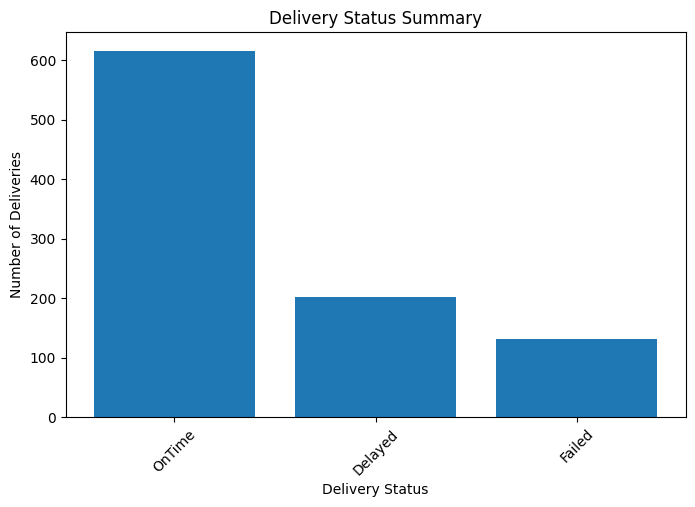

In [21]:
plt.figure(figsize=(8,5))
plt.bar(delivery_status_summary["delivery_status"], delivery_status_summary["count"])
plt.title("Delivery Status Summary")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=45)
plt.show()

In [22]:
hub_failure = deliveries.merge(hubs, on="hub_id", how="left")

hub_failure_summary = hub_failure.groupby(["hub_id", "hub_name", "zone"]).agg(
    total_deliveries=("delivery_id", "count"),
    failed_deliveries=("delivery_status", lambda x: (x == "Failed").sum())
).reset_index()

hub_failure_summary["failure_rate_percent"] = (
    hub_failure_summary["failed_deliveries"] / hub_failure_summary["total_deliveries"] * 100
).round(2)

hub_failure_summary.sort_values("failure_rate_percent", ascending=False)

,hub_id,hub_name,zone,total_deliveries,failed_deliveries,failure_rate_percent
7,H08,Midtown Relay,Central,128,26,20.31
4,H05,Central Core,Central,115,23,20.00
5,H06,Airport Hub,Airport,104,15,14.42
3,H04,West Gate,West,127,16,12.60
0,H01,North Exchange,North,136,17,12.50
6,H07,Riverside Hub,Riverside,115,14,12.17
1,H02,South Link,South,106,10,9.43
2,H03,East Dock,East,119,11,9.24


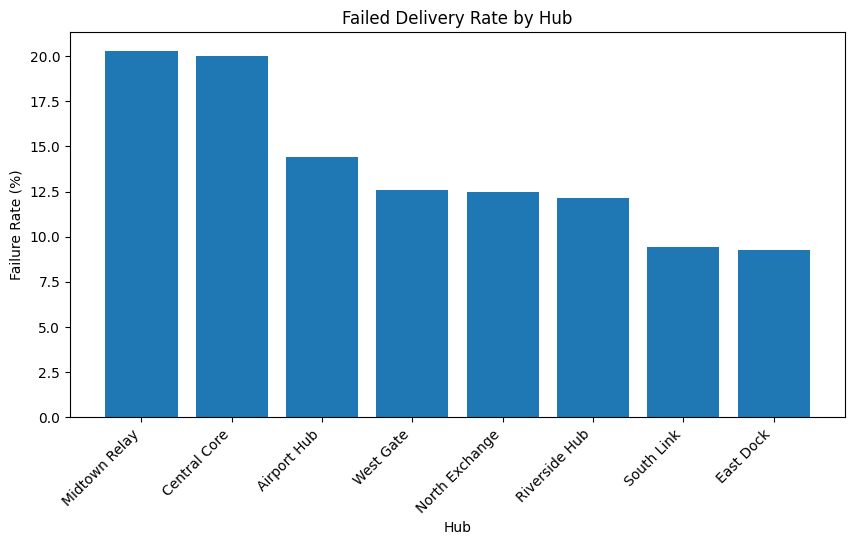

In [23]:
hub_failure_sorted = hub_failure_summary.sort_values("failure_rate_percent", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(hub_failure_sorted["hub_name"], hub_failure_sorted["failure_rate_percent"])
plt.title("Failed Delivery Rate by Hub")
plt.xlabel("Hub")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

In [24]:
hub_duration_summary = hub_failure.groupby(["hub_id", "hub_name", "zone"]).agg(
    average_delivery_hours=("delivery_duration_hours", "mean"),
    total_deliveries=("delivery_id", "count")
).reset_index()

hub_duration_summary["average_delivery_hours"] = hub_duration_summary["average_delivery_hours"].round(2)

hub_duration_summary.sort_values("average_delivery_hours", ascending=False)

,hub_id,hub_name,zone,average_delivery_hours,total_deliveries
4,H05,Central Core,Central,10.90,115
3,H04,West Gate,West,10.33,127
6,H07,Riverside Hub,Riverside,9.92,115
7,H08,Midtown Relay,Central,9.82,128
0,H01,North Exchange,North,9.38,136
5,H06,Airport Hub,Airport,9.38,104
1,H02,South Link,South,8.87,106
2,H03,East Dock,East,7.66,119


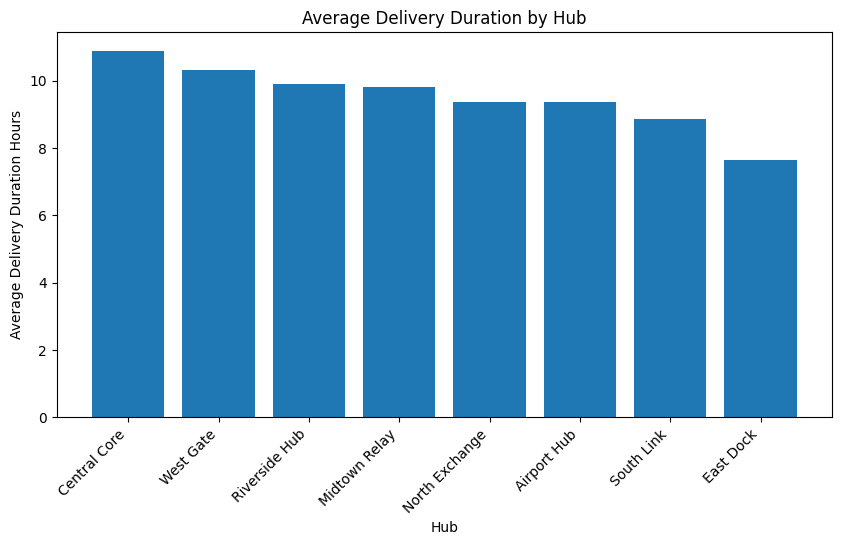

In [25]:
hub_duration_sorted = hub_duration_summary.sort_values("average_delivery_hours", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(hub_duration_sorted["hub_name"], hub_duration_sorted["average_delivery_hours"])
plt.title("Average Delivery Duration by Hub")
plt.xlabel("Hub")
plt.ylabel("Average Delivery Duration Hours")
plt.xticks(rotation=45, ha="right")
plt.show()

In [26]:
complaint_type_summary = complaints["complaint_type"].value_counts().reset_index()
complaint_type_summary.columns = ["complaint_type", "count"]

complaint_type_summary

,complaint_type,count
0,Delay,101
1,MissedPickup,64
2,AppIssue,53
3,DriverBehaviour,51
4,SupportExperience,20
5,Billing,16
6,Damage,15


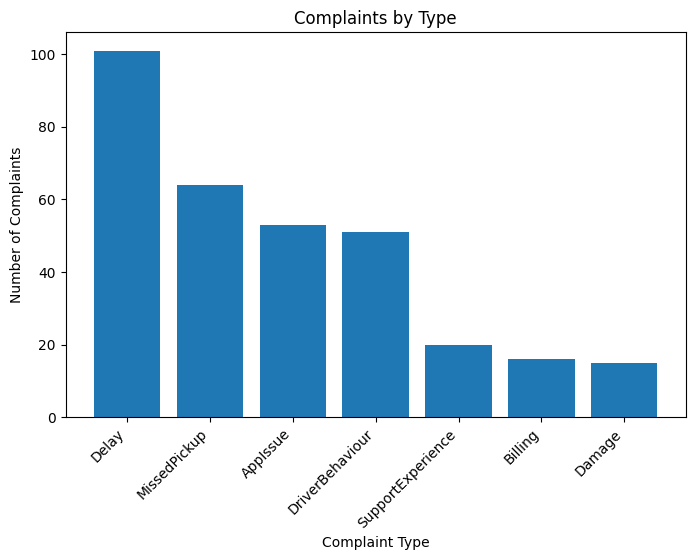

In [27]:
plt.figure(figsize=(8,5))
plt.bar(complaint_type_summary["complaint_type"], complaint_type_summary["count"])
plt.title("Complaints by Type")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")
plt.show()

In [28]:
complaint_severity_summary = complaints["severity"].value_counts().reset_index()
complaint_severity_summary.columns = ["severity", "count"]

complaint_severity_summary

,severity,count
0,Medium,172
1,High,77
2,Low,71


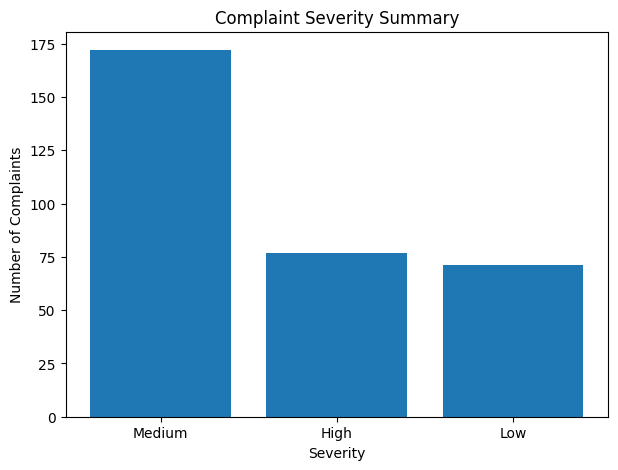

In [29]:
plt.figure(figsize=(7,5))
plt.bar(complaint_severity_summary["severity"], complaint_severity_summary["count"])
plt.title("Complaint Severity Summary")
plt.xlabel("Severity")
plt.ylabel("Number of Complaints")
plt.show()

In [30]:
override_summary = deliveries.groupby("delivery_status").agg(
    average_manual_overrides=("manual_route_override_count", "mean"),
    total_deliveries=("delivery_id", "count")
).reset_index()

override_summary["average_manual_overrides"] = override_summary["average_manual_overrides"].round(2)

override_summary

,delivery_status,average_manual_overrides,total_deliveries
0,Delayed,1.07,202
1,Failed,1.04,132
2,OnTime,0.92,616


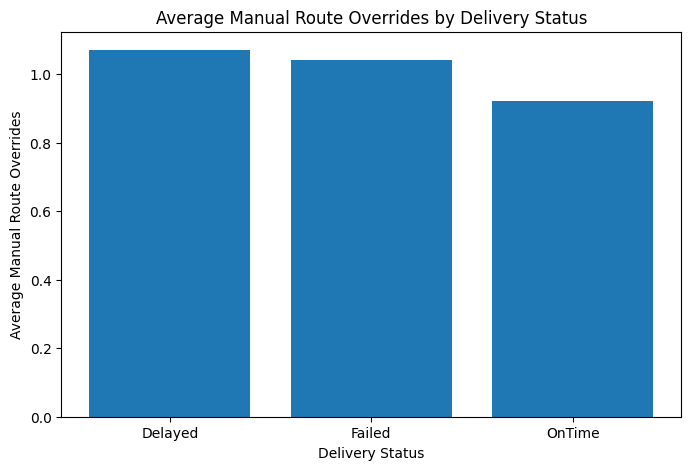

In [31]:
plt.figure(figsize=(8,5))
plt.bar(override_summary["delivery_status"], override_summary["average_manual_overrides"])
plt.title("Average Manual Route Overrides by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Manual Route Overrides")
plt.show()

In [32]:
driver_delivery = deliveries.merge(drivers, on="driver_id", how="left")

driver_performance = driver_delivery.groupby("driver_id").agg(
    total_deliveries=("delivery_id", "count"),
    failed_deliveries=("delivery_status", lambda x: (x == "Failed").sum()),
    average_rating=("driver_rating", "mean"),
    average_training_score=("training_score", "mean"),
    average_customer_rating=("customer_rating_post_delivery", "mean")
).reset_index()

driver_performance["failure_rate_percent"] = (
    driver_performance["failed_deliveries"] / driver_performance["total_deliveries"] * 100
).round(2)

driver_performance.sort_values("failure_rate_percent", ascending=False).head(10)

,driver_id,total_deliveries,failed_deliveries,average_rating,average_training_score,average_customer_rating,failure_rate_percent
50,D051,2,2,3.58,75.4,3.180000,100.00
62,D063,3,2,4.03,85.7,2.373333,66.67
91,D092,5,3,4.24,88.2,3.376000,60.00
103,D104,7,4,3.45,87.7,3.928571,57.14
169,D170,4,2,4.48,75.2,3.507500,50.00
102,D103,4,2,4.40,72.5,3.280000,50.00
110,D111,4,2,4.12,79.2,2.637500,50.00
131,D132,4,2,4.20,77.6,3.637500,50.00
23,D024,8,4,3.35,71.4,3.443750,50.00
146,D147,2,1,3.80,66.4,3.100000,50.00


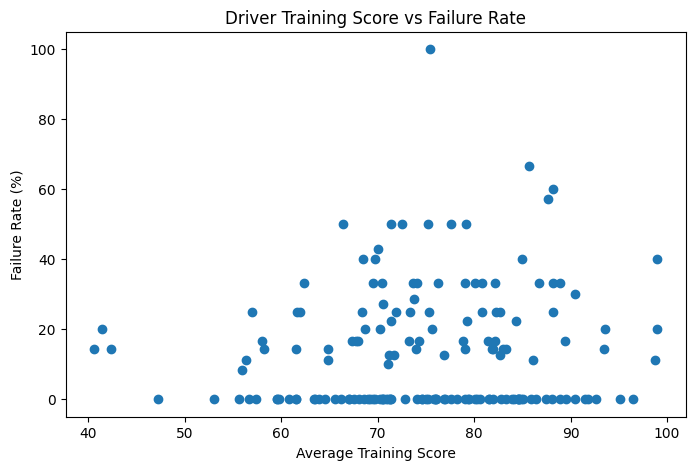

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(driver_performance["average_training_score"], driver_performance["failure_rate_percent"])
plt.title("Driver Training Score vs Failure Rate")
plt.xlabel("Average Training Score")
plt.ylabel("Failure Rate (%)")
plt.show()

In [34]:
vehicle_delivery = deliveries.merge(vehicles, on="vehicle_id", how="left")
vehicle_incidents = vehicle_delivery.merge(incidents, on="delivery_id", how="left")

vehicle_summary = vehicle_incidents.groupby("vehicle_id").agg(
    battery_health_pct=("battery_health_pct", "mean"),
    odometer_km=("odometer_km", "mean"),
    total_deliveries=("delivery_id", "nunique"),
    total_incidents=("incident_id", "count")
).reset_index()

vehicle_summary["battery_health_pct"] = vehicle_summary["battery_health_pct"].round(2)

vehicle_summary.sort_values("total_incidents", ascending=False).head(10)

,vehicle_id,battery_health_pct,odometer_km,total_deliveries,total_incidents
46,V047,93.7,134347.0,17,9
107,V108,54.6,141290.0,9,7
45,V046,95.8,101425.0,10,6
29,V030,78.0,134360.0,15,6
96,V097,92.1,18680.0,8,6
8,V009,68.8,156687.0,9,5
34,V035,83.6,73804.0,9,5
4,V005,58.6,146638.0,13,5
75,V076,65.8,106063.0,6,5
87,V088,80.3,50427.0,13,5


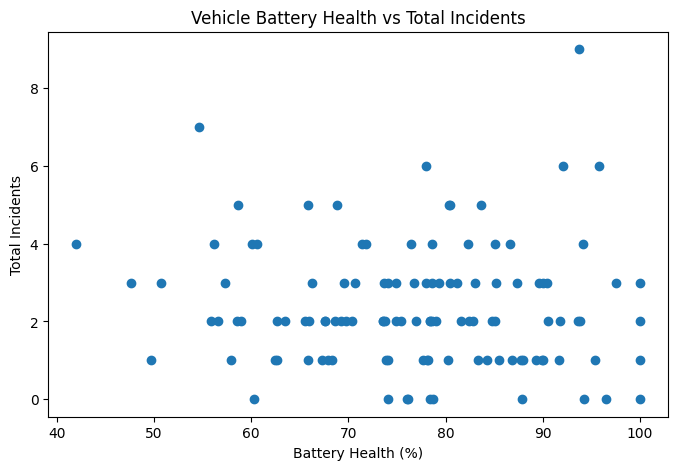

In [35]:
plt.figure(figsize=(8,5))
plt.scatter(vehicle_summary["battery_health_pct"], vehicle_summary["total_incidents"])
plt.title("Vehicle Battery Health vs Total Incidents")
plt.xlabel("Battery Health (%)")
plt.ylabel("Total Incidents")
plt.show()

## 8. Save Cleaned Outputs

In [36]:
output_path = "/content/drive/MyDrive/NorthStar_Assignment/data"

hubs.to_csv(output_path + "/clean_hubs.csv", index=False)
customers.to_csv(output_path + "/clean_customers.csv", index=False)
drivers.to_csv(output_path + "/clean_drivers.csv", index=False)
vehicles.to_csv(output_path + "/clean_vehicles.csv", index=False)
orders.to_csv(output_path + "/clean_orders.csv", index=False)
deliveries.to_csv(output_path + "/clean_deliveries.csv", index=False)
incidents.to_csv(output_path + "/clean_incidents.csv", index=False)
complaints.to_csv(output_path + "/clean_complaints.csv", index=False)
app_events.to_csv(output_path + "/clean_app_events.csv", index=False)
full_analysis.to_csv(output_path + "/full_analysis.csv", index=False)

print("Cleaned datasets saved successfully")

Cleaned datasets saved successfully
